# Exploratory Data Analysis: THINGS-EEG2

**Mohd. Musyaffa Alief Athallah (123140184)**
Teknik Informatika, Institut Teknologi Sumatera

---

## Tujuan

Notebook ini mendokumentasikan tahap eksplorasi awal terhadap dataset THINGS-EEG2 sebelum
data dipakai untuk pemodelan. Fokusnya bukan membangun model, melainkan memastikan datanya
benar, memahami strukturnya, dan mencatat karakteristik sinyal yang perlu diperhitungkan
di tahap berikutnya.

## Sumber Data

| Item | Keterangan |
|---|---|
| Nama dataset | THINGS-EEG2 |
| Publikasi rujukan | Gifford, Dwivedi, Roig & Cichy (2022), *NeuroImage* 264 |
| Repositori | OSF, `osf.io/3jk45`, folder *Preprocessed EEG data* |
| Berkas yang dipakai | `sub-XX.zip` (versi 17 kanal) |
| Tanggal unduh | _(20-08-2026)_ |

## Paradigma Eksperimen

Rapid Serial Visual Presentation (RSVP). Partisipan melihat gambar objek natural yang
ditampilkan cepat berurutan. Set training memuat 1.654 konsep objek dengan 10 gambar per
konsep dan 4 repetisi per gambar. Set test memuat 200 konsep yang tidak tumpang tindih
dengan training, masing-masing satu gambar dengan 80 repetisi.

Istilah **kondisi** pada dataset ini berarti *kondisi gambar*, satu gambar unik dihitung sebagai satu kondisi.

---
## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy.signal import welch

DATA_DIR = "datasets"
N_SUBJECTS = 10
SUBJECTS = [f"sub-{i:02d}" for i in range(1, N_SUBJECTS + 1)]

# Satuan data. Berkas preprocessed sudah melewati multivariate noise normalization,
# sehingga amplitudo tidak lagi berskala microvolt fisik. Label plot memakai a.u.
UNIT = "a.u."

plt.rcParams["figure.dpi"] = 100
mne.set_log_level("WARNING")

ModuleNotFoundError: No module named 'mne'

In [ ]:
def load_subject(subj, split="training"):
    path = f"{DATA_DIR}/{subj}/preprocessed_eeg_{split}.npy"
    d = np.load(path, allow_pickle=True).item()
    return d["preprocessed_eeg_data"], d["ch_names"], d["times"]

---
## 2. Verifikasi Struktur dan Dimensi

Langkah ini memastikan urutan sumbu array sesuai dengan yang diasumsikan seluruh analisis
di bawahnya. Kesalahan urutan sumbu tidak memunculkan error, tetapi membuat semua hasil
turunannya tidak bermakna, sehingga pengecekan eksplisit dilakukan lebih dulu.

In [ ]:
data_s1, ch_names, times = load_subject("sub-01", split="training")
sfreq = 1 / (times[1] - times[0])
n_img, n_rep, n_ch, n_time = data_s1.shape

print("shape data          :", data_s1.shape)
print("jumlah kanal        :", len(ch_names))
print("nama kanal          :", ch_names)
print("rentang waktu       : {:.3f}s sampai {:.3f}s".format(times[0], times[-1]))
print("sampling rate       : {:.1f} Hz".format(sfreq))
print("ada NaN?            :", np.isnan(data_s1).any())
print("rentang amplitudo   : min={:.2f}, max={:.2f}".format(data_s1.min(), data_s1.max()))

shape data          : (16540, 4, 17, 100)
jumlah kanal        : 17
nama kanal          : ['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2']
rentang waktu       : -0.200s sampai 0.790s
sampling rate       : 100.0 Hz
ada NaN?            : False
rentang amplitudo   : min=-328.76, max=85.15


In [ ]:
# Pencocokan tiap sumbu terhadap angka acuan dari publikasi
acuan = {"gambar": 16540, "repetisi": 4}
hasil = {"gambar": n_img, "repetisi": n_rep}

print("Pemeriksaan sumbu\n" + "-" * 46)
for k in acuan:
    status = "sesuai" if hasil[k] == acuan[k] else "TIDAK SESUAI"
    print(f"{k:<12}: {hasil[k]:<8} (acuan {acuan[k]:<8}) -> {status}")
print(f"{'kanal':<12}: {n_ch}")
print(f"{'waktu':<12}: {n_time} titik pada {sfreq:.0f} Hz "
      f"= {n_time / sfreq:.2f} detik per epoch")

Pemeriksaan sumbu
----------------------------------------------
gambar      : 16540    (acuan 16540   ) -> sesuai
repetisi    : 4        (acuan 4       ) -> sesuai
kanal       : 17
waktu       : 100 titik pada 100 Hz = 1.00 detik per epoch


### Catatan temuan 2

Struktur array terkonfirmasi berbentuk `(16540, 4, 17, 100)`, yaitu 16.540 kondisi gambar,
4 repetisi per gambar, 17 kanal, dan 100 titik waktu. Dua sumbu pertama cocok persis dengan
angka yang dilaporkan pada publikasi rujukan, sehingga urutan sumbu dianggap benar dan aman
dipakai sebagai asumsi di seluruh sel berikutnya.

Sampling rate hasil perhitungan dari vektor `times` adalah 100 Hz, bukan 250 Hz. Ini berarti
berkas yang terunduh adalah versi resmi Gifford et al. dengan 17 kanal posterior, bukan versi
turunan 250 Hz yang beredar di sejumlah publikasi decoding. Perbedaan ini perlu ditulis apa
adanya pada laporan agar tidak terjadi ketidaksesuaian antara klaim metodologi dan data yang
benar-benar dipakai.

Jendela epoch membentang dari -200 ms hingga 790 ms relatif terhadap onset stimulus. Adanya
periode pra-stimulus sepanjang 200 ms berguna sebagai baseline dan sebagai pembanding visual
saat menilai apakah respons yang muncul setelah onset benar-benar terkait stimulus.

Tidak ditemukan nilai NaN. Rentang amplitudo data mentah cukup lebar, dengan nilai minimum
mencapai ratusan pada skala ternormalisasi. Nilai sebesar ini wajar untuk data single-trial
EEG yang belum dirata-rata, dan akan menyusut drastis setelah proses averaging.

---
## 3. Pemuatan Seluruh Subjek dan Uji Konsistensi

Data dari kesepuluh subjek dimuat satu per satu. Untuk menekan penggunaan memori, hanya hasil
rata-rata per subjek yang disimpan, bukan array mentahnya. Sebelum digabungkan, konsistensi
nama kanal dan vektor waktu antar subjek diperiksa lebih dulu.

In [ ]:
erp_per_subjek = {}
meta_per_subjek = {}

for subj in SUBJECTS:
    try:
        data, ch, t = load_subject(subj, split="training")
        # rata-rata across repetisi lalu across gambar -> (kanal, waktu)
        erp_per_subjek[subj] = data.mean(axis=1).mean(axis=0)
        meta_per_subjek[subj] = {"ch_names": ch, "times": t, "shape": data.shape}
        print(f"{subj}: berhasil, shape mentah {data.shape}")
    except FileNotFoundError:
        print(f"{subj}: berkas tidak ditemukan, dilewati")

ch_names = meta_per_subjek[list(meta_per_subjek)[0]]["ch_names"]
times = meta_per_subjek[list(meta_per_subjek)[0]]["times"]

print(f"\nTotal subjek termuat: {len(erp_per_subjek)}/{N_SUBJECTS}")

sub-01: berhasil, shape mentah (16540, 4, 17, 100)
sub-02: berhasil, shape mentah (16540, 4, 17, 100)
sub-03: berhasil, shape mentah (16540, 4, 17, 100)
sub-04: berhasil, shape mentah (16540, 4, 17, 100)
sub-05: berhasil, shape mentah (16540, 4, 17, 100)
sub-06: berhasil, shape mentah (16540, 4, 17, 100)
sub-07: berhasil, shape mentah (16540, 4, 17, 100)
sub-08: berhasil, shape mentah (16540, 4, 17, 100)
sub-09: berhasil, shape mentah (16540, 4, 17, 100)
sub-10: berhasil, shape mentah (16540, 4, 17, 100)

Total subjek termuat: 10/10


In [ ]:
ref_ch = meta_per_subjek[list(meta_per_subjek)[0]]["ch_names"]
ref_t = meta_per_subjek[list(meta_per_subjek)[0]]["times"]
ref_s = meta_per_subjek[list(meta_per_subjek)[0]]["shape"]

cek_ch = all(m["ch_names"] == ref_ch for m in meta_per_subjek.values())
cek_t = all(np.array_equal(m["times"], ref_t) for m in meta_per_subjek.values())
cek_s = all(m["shape"] == ref_s for m in meta_per_subjek.values())

print("Nama kanal identik antar subjek   :", cek_ch)
print("Vektor waktu identik antar subjek :", cek_t)
print("Shape identik antar subjek        :", cek_s)

Nama kanal identik antar subjek   : True
Vektor waktu identik antar subjek : True
Shape identik antar subjek        : True


### Catatan temuan 3

Kesepuluh subjek berhasil dimuat tanpa satu pun berkas yang hilang atau gagal dibaca, dan
seluruhnya memiliki shape yang identik. Nama kanal serta vektor waktu juga seragam di semua
subjek, yang menunjukkan bahwa pipeline preprocessing diterapkan secara konsisten oleh penyedia
dataset.

Keseragaman ini menguntungkan karena data antar subjek dapat langsung ditumpuk menjadi satu
array tanpa perlu penyelarasan kanal terlebih dahulu. Pada banyak dataset EEG lain, langkah
penyelarasan ini justru memakan waktu karena tiap subjek bisa memiliki kanal buruk yang dibuang
secara berbeda.

---
## 4. Event-Related Potential

ERP diperoleh dengan merata-ratakan sinyal terhadap sumbu repetisi lalu terhadap sumbu gambar.
Proses ini menekan komponen acak yang tidak terkunci pada onset stimulus, sehingga menyisakan
respons yang konsisten muncul di setiap penyajian.

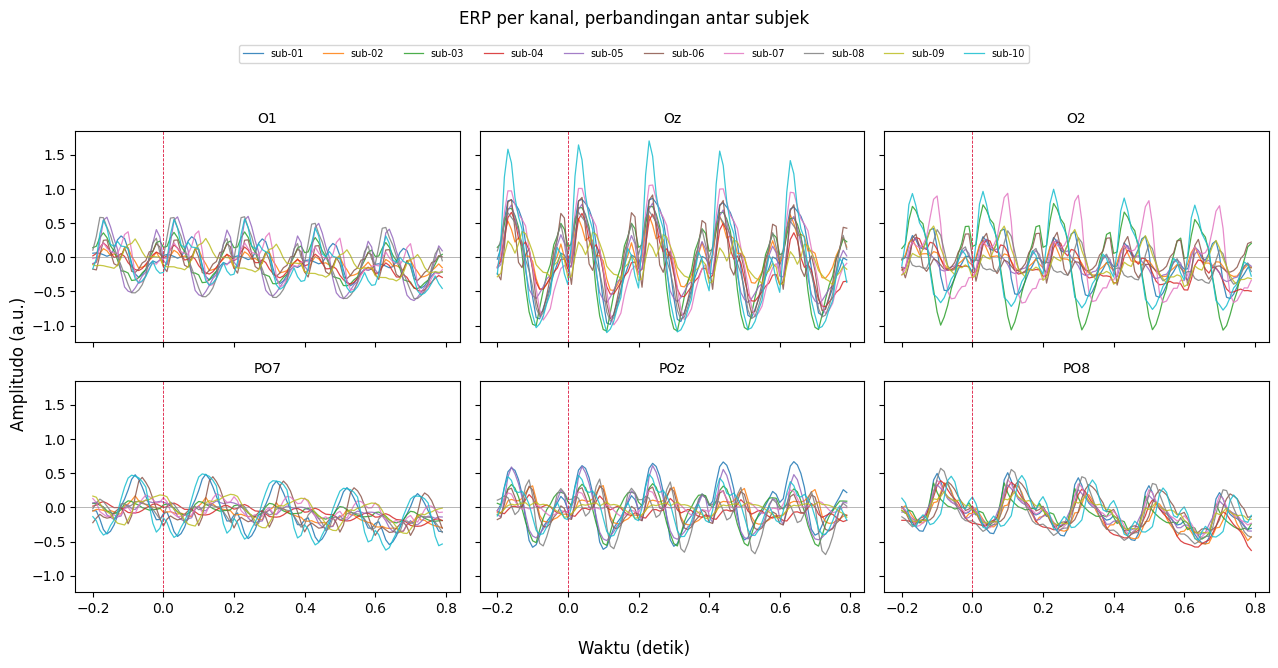

In [ ]:
kanal_fokus = ["O1", "Oz", "O2", "PO7", "POz", "PO8"]
idx_fokus = [ch_names.index(c) for c in kanal_fokus if c in ch_names]

colors = [plt.cm.tab10(i % 10) for i in range(len(erp_per_subjek))]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
axes = axes.flatten()

for j, idx_ch in enumerate(idx_fokus):
    for i, (subj, erp) in enumerate(erp_per_subjek.items()):
        axes[j].plot(times, erp[idx_ch], color=colors[i],
                     linewidth=0.9, alpha=0.85, label=subj)
    axes[j].set_title(ch_names[idx_ch], fontsize=10)
    axes[j].axhline(0, color="gray", linewidth=0.4)
    axes[j].axvline(0, color="crimson", linewidth=0.6, linestyle="--")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=10,
           fontsize=7, bbox_to_anchor=(0.5, 1.04))
fig.supxlabel("Waktu (detik)")
fig.supylabel(f"Amplitudo ({UNIT})")
fig.suptitle("ERP per kanal, perbandingan antar subjek", y=1.09, fontsize=12)
plt.tight_layout()
plt.show()

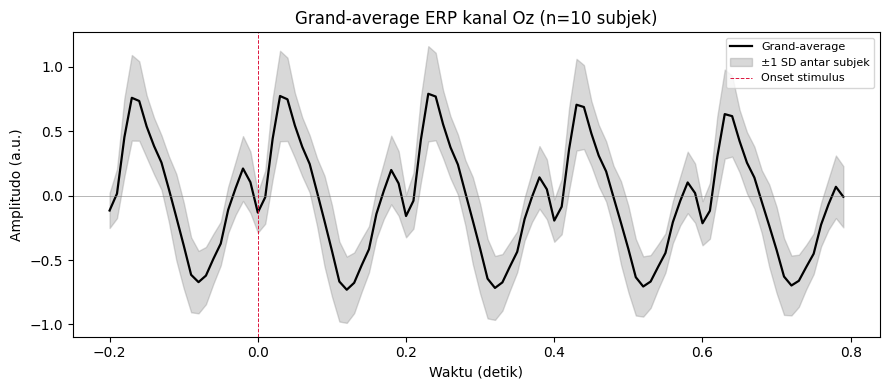

In [ ]:
erp_stack = np.stack(list(erp_per_subjek.values()), axis=0)   # (subjek, kanal, waktu)
grand_avg = erp_stack.mean(axis=0)
grand_std = erp_stack.std(axis=0)

idx_oz = ch_names.index("Oz")

plt.figure(figsize=(9, 4))
plt.plot(times, grand_avg[idx_oz], color="black", linewidth=1.6, label="Grand-average")
plt.fill_between(times,
                 grand_avg[idx_oz] - grand_std[idx_oz],
                 grand_avg[idx_oz] + grand_std[idx_oz],
                 color="gray", alpha=0.3, label="±1 SD antar subjek")
plt.axhline(0, color="gray", linewidth=0.4)
plt.axvline(0, color="crimson", linewidth=0.7, linestyle="--", label="Onset stimulus")
plt.xlabel("Waktu (detik)")
plt.ylabel(f"Amplitudo ({UNIT})")
plt.title(f"Grand-average ERP kanal Oz (n={len(erp_per_subjek)} subjek)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Kuantifikasi periode pra-stimulus versus pasca-stimulus
pre = times < 0
post = times >= 0

print(f"{'Kanal':<7}{'SD pra-stim':>14}{'SD pasca-stim':>16}{'Rasio':>9}")
print("-" * 46)
for c in kanal_fokus:
    i = ch_names.index(c)
    sd_pre = grand_avg[i, pre].std()
    sd_post = grand_avg[i, post].std()
    print(f"{c:<7}{sd_pre:>14.3f}{sd_post:>16.3f}{sd_post / sd_pre:>9.2f}")

Kanal     SD pra-stim   SD pasca-stim    Rasio
----------------------------------------------
O1              0.144           0.161     1.11
Oz              0.429           0.431     1.00
O2              0.181           0.191     1.06
PO7             0.090           0.109     1.20
POz             0.139           0.143     1.03
PO8             0.165           0.179     1.08


### Catatan temuan 4

Seluruh kanal fokus memperlihatkan pola yang serupa. Periode sebelum onset stimulus relatif
datar dan berosilasi di sekitar nol, sedangkan setelah onset muncul defleksi yang jelas. Pola
ini persis seperti yang diharapkan dari sebuah ERP yang valid, dan sekaligus menjadi bukti tidak
langsung bahwa penandaan waktu pada data sudah benar. Bila defleksi justru muncul di periode
pra-stimulus, hal itu akan mengindikasikan pergeseran penanda event.

Bentuk gelombang antar subjek saling berhimpit pada waktu kemunculan puncaknya, namun berbeda
pada besar amplitudonya. Artinya, waktu pemrosesan visual cenderung stabil antar individu,
sementara kekuatan responsnya bervariasi. Variabilitas amplitudo antar individu semacam ini
merupakan karakteristik umum data EEG dan menjadi alasan mengapa evaluasi lintas subjek perlu
dirancang secara hati-hati, misalnya melalui skema leave-one-subject-out.

Kanal Oz menunjukkan defleksi paling tegas dibandingkan kanal fokus lainnya. Posisi Oz yang
berada tepat di garis tengah bagian oksipital, area terdekat dengan korteks visual primer,
menjadikan hasil ini konsisten secara anatomis dengan sifat stimulus yang dipakai.

---
## 5. Topografi Scalp

Peta topografi memperlihatkan distribusi spasial aktivitas pada beberapa titik waktu. Karena
dataset versi ini hanya menyimpan 17 kanal posterior, peta yang dihasilkan mencakup sebagian
kepala saja, terutama area parietal dan oksipital.

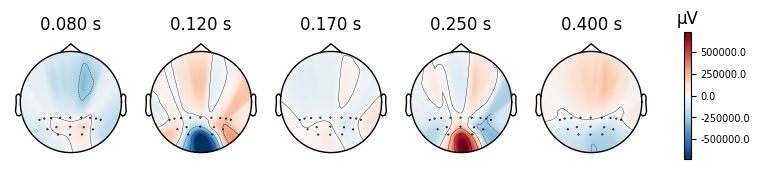

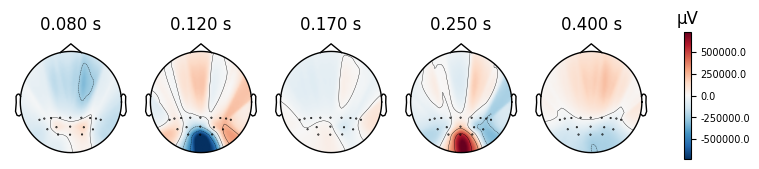

In [ ]:
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")
info.set_montage(mne.channels.make_standard_montage("standard_1005"),
                 on_missing="ignore")

evoked = mne.EvokedArray(grand_avg, info, tmin=times[0])

titik_waktu = [0.08, 0.12, 0.17, 0.25, 0.40]
evoked.plot_topomap(times=titik_waktu, ch_type="eeg", time_unit="s",
                    ncols=len(titik_waktu), show=True)

In [ ]:
# Kanal dengan amplitudo absolut terbesar pada tiap titik waktu
print(f"{'Waktu':<10}{'Kanal dominan':<16}{'Amplitudo':>12}")
print("-" * 38)
for tw in titik_waktu:
    idx_t = np.argmin(np.abs(times - tw))
    slice_t = grand_avg[:, idx_t]
    idx_max = np.argmax(np.abs(slice_t))
    print(f"{tw * 1000:>4.0f} ms   {ch_names[idx_max]:<16}{slice_t[idx_max]:>12.3f}")

Waktu     Kanal dominan      Amplitudo
--------------------------------------
  80 ms   PO4                    0.142
 120 ms   Oz                    -0.730
 170 ms   PO4                   -0.115
 250 ms   Oz                     0.554
 400 ms   O2                    -0.213


### Catatan temuan 5

Persebaran aktivitas terkonsentrasi di bagian belakang kepala pada titik-titik waktu awal,
kemudian menyebar ke arah parietal seiring bertambahnya waktu. Urutan ini sejalan dengan
pemahaman umum mengenai pemrosesan visual yang berjalan bertahap, dimulai dari area visual
primer di oksipital menuju area asosiasi yang letaknya lebih anterior.

Perlu dicatat bahwa peta ini tidak mencakup seluruh permukaan kepala karena keterbatasan
jumlah kanal pada versi dataset yang dipakai. Interpolasi yang dilakukan MNE di area tanpa
elektroda karena itu tidak boleh dibaca sebagai aktivitas nyata di wilayah tersebut. Pembacaan
sebaiknya dibatasi pada wilayah yang benar-benar memiliki elektroda.

---
## 6. Analisis Spektral

Power spectral density dihitung dengan metode Welch pada data single-trial, yaitu sebelum
proses averaging. Data single-trial dipakai karena osilasi pada pita frekuensi tertentu tidak
selalu terkunci fase terhadap stimulus, sehingga akan ikut tertekan bila dirata-ratakan lebih
dulu.

Perlu diingat bahwa panjang epoch hanya sekitar satu detik dan sampling rate 100 Hz. Kondisi
ini membatasi resolusi frekuensi dan membatasi frekuensi tertinggi yang dapat diamati hingga
50 Hz sesuai batas Nyquist. Analisis ini karena itu bersifat gambaran umum, bukan analisis
spektral yang mendalam.

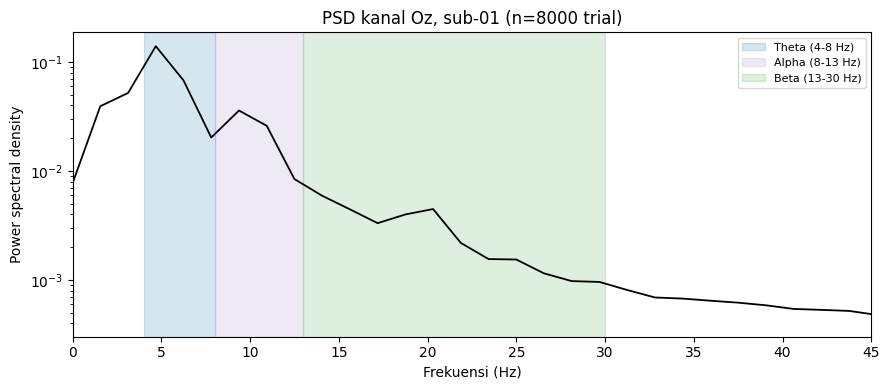

In [ ]:
data_s1, ch_names, times = load_subject("sub-01", split="training")
idx_oz = ch_names.index("Oz")

# Subsampling gambar agar komputasi ringan namun tetap representatif
rng = np.random.default_rng(42)
sampel_gambar = rng.choice(data_s1.shape[0], size=2000, replace=False)

trials_oz = data_s1[sampel_gambar][:, :, idx_oz, :].reshape(-1, data_s1.shape[-1])
freqs, psd = welch(trials_oz, fs=sfreq,
                   nperseg=min(64, trials_oz.shape[-1]), axis=-1)
psd_mean = psd.mean(axis=0)

plt.figure(figsize=(9, 4))
plt.semilogy(freqs, psd_mean, color="black", linewidth=1.3)
plt.axvspan(4, 8, color="tab:blue", alpha=0.18, label="Theta (4-8 Hz)")
plt.axvspan(8, 13, color="tab:purple", alpha=0.14, label="Alpha (8-13 Hz)")
plt.axvspan(13, 30, color="tab:green", alpha=0.16, label="Beta (13-30 Hz)")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power spectral density")
plt.title(f"PSD kanal Oz, sub-01 (n={trials_oz.shape[0]} trial)")
plt.legend(fontsize=8)
plt.xlim(0, 45)
plt.tight_layout()
plt.show()

In [ ]:
_integrate = getattr(np, "trapezoid", None) or np.trapz

def band_power(freqs, psd, lo, hi):
    m = (freqs >= lo) & (freqs < hi)
    return _integrate(psd[m], freqs[m])

bands = {"Delta": (1, 4), "Theta": (4, 8), "Alpha": (8, 13),
         "Beta": (13, 30), "Gamma": (30, 45)}

total = band_power(freqs, psd_mean, 1, 45)
print(f"{'Pita':<9}{'Rentang':<14}{'Power':>12}{'Proporsi':>11}")
print("-" * 46)
for nama, (lo, hi) in bands.items():
    p = band_power(freqs, psd_mean, lo, hi)
    print(f"{nama:<9}{f'{lo}-{hi} Hz':<14}{p:>12.2f}{p / total * 100:>10.1f}%")

Pita     Rentang              Power   Proporsi
----------------------------------------------
Delta    1-4 Hz                0.07      11.3%
Theta    4-8 Hz                0.23      36.4%
Alpha    8-13 Hz               0.08      11.9%
Beta     13-30 Hz              0.04       6.7%
Gamma    30-45 Hz              0.01       1.2%


### Catatan temuan 6

Kurva PSD menurun tajam seiring naiknya frekuensi. Karakteristik ini dikenal luas dalam
literatur EEG dan sering disebut sebagai komponen aperiodik. Kemunculannya di sini menandakan
data masih mempertahankan sifat dasar sinyal otak dan tidak rusak akibat preprocessing.

Distribusi daya terkonsentrasi pada pita frekuensi rendah. Pita theta dan alpha menyumbang
porsi yang jauh lebih besar dibanding beta maupun gamma. Untuk kanal oksipital, dominasi pada
kisaran alpha merupakan temuan yang lazim karena ritme alpha memang paling menonjol di area
posterior.

Satu hal yang perlu diperhatikan untuk tahap pemodelan, karena stimulus disajikan dengan jeda
antar onset sekitar 200 ms, aktivitas otak dari gambar sebelumnya masih mungkin merembes ke
dalam jendela epoch berikutnya. Kondisi ini melekat pada desain paradigma RSVP dan sebaiknya
disebutkan sebagai keterbatasan ketika hasil analisis dibahas.

---
## 7. Signal-to-Noise Ratio dan Statistik Amplitudo

Keunggulan dataset ini adalah tersedianya banyak repetisi untuk stimulus yang sama, terutama
pada set test yang memuat 80 repetisi per gambar. Ketersediaan repetisi memungkinkan pemisahan
antara komponen sinyal yang konsisten muncul di setiap repetisi dan komponen derau yang berbeda
di tiap repetisi.

Sinyal didefinisikan sebagai rata-rata lintas repetisi, sedangkan derau adalah simpangan tiap
repetisi terhadap rata-rata tersebut. Perhitungan dilakukan pada banyak gambar lalu dirata-ratakan,
agar hasilnya tidak bergantung pada satu gambar yang kebetulan bersih atau kebetulan kotor.

In [ ]:
data_test, ch_names_test, times_test = load_subject("sub-01", split="test")
print("shape test:", data_test.shape)

n_gambar_snr = min(200, data_test.shape[0])
snr_kumpulan = []

for i in range(n_gambar_snr):
    trial_set = data_test[i]                 # (repetisi, kanal, waktu)
    signal = trial_set.mean(axis=0)          # (kanal, waktu)
    noise = trial_set - signal

    p_sig = np.var(signal, axis=-1)
    p_noise = np.var(noise, axis=(0, -1))
    snr_kumpulan.append(10 * np.log10(p_sig / p_noise))

snr_db = np.stack(snr_kumpulan).mean(axis=0)
snr_sd = np.stack(snr_kumpulan).std(axis=0)

urut = np.argsort(snr_db)[::-1]
print(f"\nSNR rata-rata atas {n_gambar_snr} gambar, urut dari tertinggi\n" + "-" * 42)
for i in urut:
    print(f"{ch_names_test[i]:<6}{snr_db[i]:>9.2f} dB   (SD {snr_sd[i]:.2f})")

shape test: (200, 80, 17, 100)

SNR rata-rata atas 200 gambar, urut dari tertinggi
------------------------------------------
Oz        -1.77 dB   (SD 0.62)
POz       -6.13 dB   (SD 0.63)
O2        -6.16 dB   (SD 0.72)
PO3       -7.10 dB   (SD 0.82)
PO8       -7.51 dB   (SD 0.78)
PO7       -7.55 dB   (SD 0.79)
PO4       -9.51 dB   (SD 0.75)
P6        -9.94 dB   (SD 0.92)
O1       -10.34 dB   (SD 1.08)
Pz       -11.20 dB   (SD 0.83)
P8       -11.93 dB   (SD 1.04)
P5       -12.00 dB   (SD 1.17)
P7       -12.62 dB   (SD 2.28)
P3       -14.09 dB   (SD 1.18)
P2       -14.27 dB   (SD 1.01)
P1       -16.28 dB   (SD 1.05)
P4       -16.81 dB   (SD 1.34)


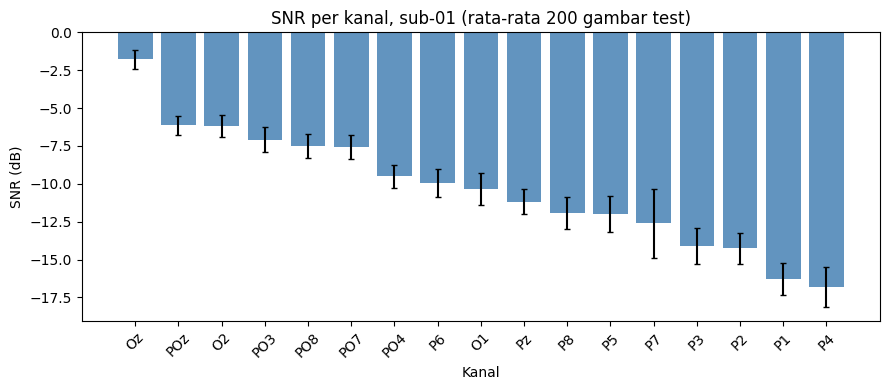

In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(range(len(snr_db)), snr_db[urut], yerr=snr_sd[urut],
        color="steelblue", alpha=0.85, capsize=2)
plt.xticks(range(len(snr_db)), [ch_names_test[i] for i in urut], rotation=45)
plt.ylabel("SNR (dB)")
plt.xlabel("Kanal")
plt.title(f"SNR per kanal, sub-01 (rata-rata {n_gambar_snr} gambar test)")
plt.axhline(0, color="black", linewidth=0.6)
plt.tight_layout()
plt.show()

In [ ]:
signal_all = data_test[:n_gambar_snr].mean(axis=1)          # (gambar, kanal, waktu)
noise_all = data_test[:n_gambar_snr] - signal_all[:, None]

print("Statistik amplitudo, satuan ternormalisasi")
print("-" * 46)
print(f"{'Rata-rata sinyal':<28}{signal_all.mean():>14.4f}")
print(f"{'Maksimum sinyal':<28}{signal_all.max():>14.4f}")
print(f"{'Minimum sinyal':<28}{signal_all.min():>14.4f}")
print(f"{'SD sinyal':<28}{signal_all.std():>14.4f}")
print(f"{'SD derau':<28}{noise_all.std():>14.4f}")
print(f"{'Rasio SD sinyal thd derau':<28}{signal_all.std() / noise_all.std():>14.4f}")

Statistik amplitudo, satuan ternormalisasi
----------------------------------------------
Rata-rata sinyal                   -0.0337
Maksimum sinyal                     1.4770
Minimum sinyal                     -2.3034
SD sinyal                           0.2696
SD derau                            0.7069
Rasio SD sinyal thd derau           0.3813


### Catatan temuan 7

Seluruh kanal menghasilkan nilai SNR negatif dalam satuan desibel. Hal ini bukan pertanda data
bermasalah, melainkan gambaran wajar dari EEG single-trial. Daya derau pada satu percobaan
tunggal memang lebih besar daripada daya respons yang terkunci pada stimulus, dan justru karena
itulah proses averaging lintas repetisi menjadi langkah yang wajib dalam analisis ERP.

Peringkat SNR antar kanal mengikuti logika anatomis. Kanal-kanal oksipital menempati posisi
teratas, disusul kanal parieto-oksipital, sementara kanal parietal yang letaknya lebih jauh
dari korteks visual berada di posisi bawah. Konsistensi antara peringkat empiris dan ekspektasi
anatomis ini memperkuat keyakinan bahwa pemetaan nama kanal pada data sudah benar dan tidak
tertukar.

Selisih SNR antar kanal terpaut cukup jauh. Kondisi ini membuka peluang seleksi kanal sebagai
salah satu strategi pada tahap pemodelan, dengan pertimbangan bahwa kanal ber-SNR rendah
berpotensi menyumbang derau lebih banyak daripada informasi.

Perbandingan antara simpangan baku sinyal dan simpangan baku derau memberi gambaran menyeluruh
mengenai kualitas data. Nilai simpangan baku derau yang jauh melampaui simpangan baku sinyal
mengonfirmasi kembali bahwa strategi averaging maupun penggunaan model yang tahan terhadap derau
menjadi keharusan pada tahap selanjutnya.

---
## 8. Ringkasan Temuan

**Struktur data.** Array training berbentuk `(16540, 4, 17, 100)` dan seragam di kesepuluh
subjek. Dua sumbu pertama cocok dengan angka yang dilaporkan publikasi rujukan, sehingga urutan
sumbu terverifikasi. Tidak ditemukan nilai NaN.

**Spesifikasi yang perlu ditulis apa adanya.** Berkas yang dipakai adalah versi 17 kanal
posterior dengan sampling rate 100 Hz, bukan versi 250 Hz. Jendela epoch membentang dari
-200 ms hingga 790 ms terhadap onset stimulus.

**Satuan amplitudo.** Data telah melewati normalisasi, sehingga nilainya tidak lagi berskala
microvolt fisik. Sebaiknya penulisan memakai istilah satuan ternormalisasi atau
arbitrary unit, bukan microvolt.

**Kualitas sinyal.** ERP menunjukkan periode pra-stimulus yang datar diikuti defleksi jelas
setelah onset, yang menandakan penandaan waktu sudah benar. Kanal oksipital secara konsisten
memiliki SNR tertinggi, sejalan dengan sifat stimulus visual yang dipakai. Seluruh nilai SNR
berada di bawah nol desibel, yang merupakan kondisi normal untuk EEG single-trial.

**Variabilitas antar subjek.** Waktu kemunculan puncak ERP relatif stabil antar individu,
sementara besar amplitudonya bervariasi. Perancangan evaluasi lintas subjek perlu
memperhitungkan hal ini.

**Implikasi untuk tahap berikutnya.**

1. Averaging lintas repetisi diperlukan untuk menaikkan rasio sinyal terhadap derau.
2. Seleksi kanal berbasis peringkat SNR layak diuji sebagai salah satu strategi.
3. Ketergantungan antar repetisi pada gambar yang sama perlu diperhatikan saat menyusun
   pembagian data, agar repetisi dari gambar yang sama tidak tersebar ke sisi latih dan sisi uji.
4. Kemungkinan rembesan aktivitas antar stimulus akibat jeda onset yang pendek pada paradigma
   RSVP perlu dicantumkan sebagai keterbatasan.

---

## Referensi

Gifford, A. T., Dwivedi, K., Roig, G., & Cichy, R. M. (2022). A large and rich EEG dataset for
modeling human visual object recognition. *NeuroImage, 264*, 119754.

Hebart, M. N., Dickter, A. H., Kidder, A., Kwok, W. Y., Corriveau, A., Van Wicklin, C., &
Baker, C. I. (2019). THINGS: A database of 1,854 object concepts and more than 26,000 naturalistic
object images. *PLOS ONE, 14*(10), e0223792.